# Overview (Male Candidate)

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

import pandas as pd
import pickle
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sys

from scipy import stats
from importlib.metadata import version

# set seaborn theme
sns.set_theme()

# python modules
import utilities as u
import plot
import ranker

# initializing variables
SEED = 1776

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    # "Sk-Learn": sys.modules['sklearn'].__version__,
    "Scipy": sys.modules['scipy'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

   Library  Version
0   Python  3.11.13
1   Pandas    2.3.1
2    NumPy    2.3.2
3  Seaborn   0.13.2
4  Matplot   3.10.5
5    Scipy   1.16.1


## Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/Candidate_Male_Heart.pkl")
# display shape
df.shape

(20737, 139)

## Male

In [3]:
# display info
df.info(max_cols=df.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 20737 entries, 0 to 28750
Data columns (total 139 columns):
 #    Column                                        Non-Null Count  Dtype   
---   ------                                        --------------  -----   
 0    PreviousTransplantNumber_CAN                  20737 non-null  category
 1    WaitListDiagnosisCode_CAN                     20737 non-null  category
 2    Gender_CAN                                    20737 non-null  category
 3    BloodGroup_CAN                                20737 non-null  category
 4    Citizenship_CAN                               20737 non-null  category
 5    ResidencyStateRegistration_CAN                20737 non-null  category
 6    EducationLevel_CAN                            20737 non-null  category
 7    LifeSupportRegistration_ECMO_CAN              20737 non-null  category
 8    LifeSupportRegistration_IABP_CAN              20737 non-null  category
 9    LifeSupportInhaled_CAN                    

In [4]:
# Empty DataFrame # list for record keeping
mapping_df = pd.DataFrame(columns=['feature', 'consolidate', 'type', 'gender'])
gender_value = 'Male'
type_value = 'CAN'
remove_cols = []

| Feature                     | Bonferroni        | Holm‑Bonferroni   | FDR (Benjamini–Hochberg) |
|-----------------------------|-------------------|-------------------|---------------------------|
| **Strictness**              | Highest           | High              | Lowest                    |
| **Statistical Power**       | Lowest            | Moderate          | Highest                   |
| **Primary Risk**            | Type II Error     | Type II Error     | Type I Error              |
| **Best Use Case**           | 2–5 comparisons; scientific “proof” | General use; balanced control | Feature engineering; large category sets |


| Error Type     | Meaning                                      | Risk in Medical Modeling                        | Caused By                          |
|----------------|----------------------------------------------|--------------------------------------------------|------------------------------------|
| **Type I**     | False positive (detecting a difference that isn't real) | Over-splitting, spurious risk groups, misleading clinical interpretation | Too lenient alpha, weak correction |
| **Type II**    | False negative (missing a real difference)    | Collapsing meaningful categories, losing signal, underestimating risk     | Low power, strict correction, small effects |



#### Previous Transplant Number

In [5]:
# info
feature = u.get_feature_info(df, 'PreviousTransplantNumber', cat=False)
# dtype
df[feature].apply(lambda s: repr(s.dtype))

                              count  unique  top   freq
PreviousTransplantNumber_CAN  20737       4    0  20192

:::: NaN Count:
PreviousTransplantNumber_CAN    0 



PreviousTransplantNumber_CAN    CategoricalDtype(categories=[0, 1, 2, 3], ordered=True, categories_dtype=int64)
dtype: object

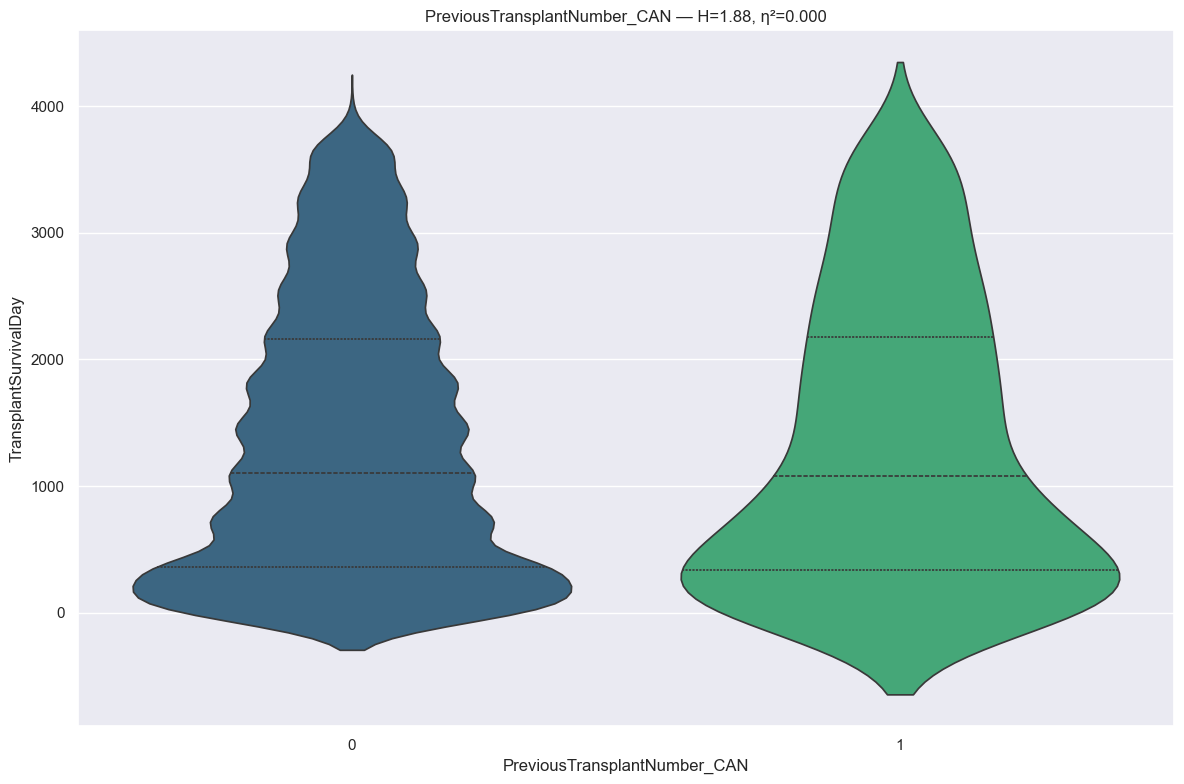

RANKING REPORT: PreviousTransplantNumber_CAN (n ≥ 30)
INCLUDED CATEGORIES:
 * 0                                                 :  20192 records
 * 1                                                 :    523 records
BYPASSED CATEGORIES (n < min_n):
 * 2                                                 :     20 records
 * 3                                                 :      2 records
--------------------------------------------------------------------------------
Kruskal H: 1.8784 | P-value: 1.705106e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
0            vs 1            | p=1.7051e-01 | thr=0.0500 | r=-0.035 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - 0
  - 1

>>> Other (2 categories)
  - 2
  - 3


In [6]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni", # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [7]:
# change to string
df[feature[0]] = df[feature[0]].astype(str)
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'2': 'Other',
           '3': 'Other'}
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

PreviousTransplantNumber_CAN  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                           0         1330.275357                1100.0                 3956.0                    0.0         20192
                           1         1295.095602                1078.0                 3704.0                    0.0           523
                       Other         1438.681818                1086.0                 3626.0                  151.0            22


In [8]:
# values for NominalSurvivalRanker
class_values = {"method": "holm"} # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: PreviousTransplantNumber_CAN (n ≥ 30)
INCLUDED CATEGORIES:
 * 0                                                 :  20192 records
 * 1                                                 :    523 records
BYPASSED CATEGORIES (n < min_n):
 * Other                                             :     22 records
--------------------------------------------------------------------------------
Kruskal H: 1.8784 | P-value: 1.705106e-01 | Effect η²: 0.0000
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.10)
--------------------------------------------------------------------------------
0            vs 1            | p=1.7051e-01 | thr=0.0500 | r=-0.035 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - 0
  - 1

>>> Other (1 categories)
  - Other



In [10]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"} 

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: PreviousTransplantNumber_CAN (n ≥ 30)
INCLUDED CATEGORIES:
 * 0                                                 :  20192 records
 * 1                                                 :    523 records
BYPASSED CATEGORIES (n < min_n):
 * Other                                             :     22 records
--------------------------------------------------------------------------------
Kruskal H: 1.8784 | P-value: 1.705106e-01 | Effect η²: 0.0000
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
0            vs 1            | p=1.7051e-01 | fdr_alpha=0.05 | r=-0.035 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - 0
  - 1

>>> Other (1 categories)
  - Other



In [9]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### WaitList Diagnosis Code

In [10]:
# info
feature = u.get_feature_info(df, 'WaitListDiagnosisCode', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                           count unique                           top  freq
WaitListDiagnosisCode_CAN  20737     36  DILATED MYOPATHY: IDIOPATHIC  7136

:::: NaN Count:
WaitListDiagnosisCode_CAN    0 



{'WaitListDiagnosisCode_CAN': CategoricalDtype(categories=['ARRHYTHMOGENIC RIGHT VENTRICULAR DYSPLASIA/CARDIOMYOPATHY',
                   'CANCER',
                   'CONGENITAL HEART DEFECT - HYPOPLASTIC LEFT HEART SYNDROME - UNOPERATED',
                   'CONGENITAL HEART DEFECT - PRIOR SURGERY UNKNOWN',
                   'CONGENITAL HEART DEFECT - WITH SURGERY',
                   'CONGENITAL HEART DEFECT - WITHOUT SURGERY',
                   'CORONARY ARTERY DISEASE',
                   'COVID-19: DILATED MYOPATHY: ACTIVE MYOCARDITIS',
                   'COVID-19: DILATED MYOPATHY: HISTORY OF MYOCARDITIS',
                   'DILATED MYOPATHY: ADRIAMYCIN',
                   'DILATED MYOPATHY: ALCOHOLIC', 'DILATED MYOPATHY: FAMILIAL',
                   'DILATED MYOPATHY: IDIOPATHIC', 'DILATED MYOPATHY: ISCHEMIC',
                   'DILATED MYOPATHY: MYOCARDITIS',
                   'DILATED MYOPATHY: OTHER SPECIFY',
                   'DILATED MYOPATHY: POST PARTUM', 'DILA

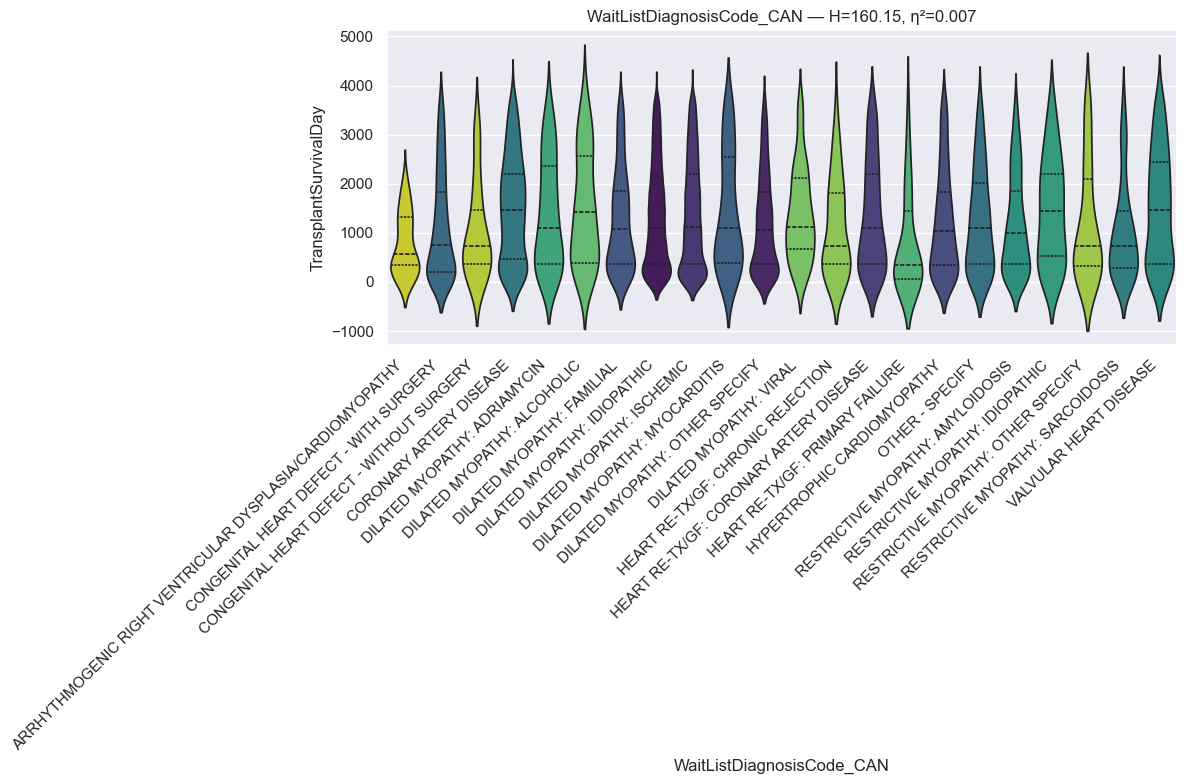

RANKING REPORT: WaitListDiagnosisCode_CAN (n ≥ 30)
INCLUDED CATEGORIES:
 * ARRHYTHMOGENIC RIGHT VENTRICULAR DYSPLASIA/CARDIOMYOPATHY:     84 records
 * CONGENITAL HEART DEFECT - WITH SURGERY            :    522 records
 * CONGENITAL HEART DEFECT - WITHOUT SURGERY         :     45 records
 * CORONARY ARTERY DISEASE                           :    602 records
 * DILATED MYOPATHY: ADRIAMYCIN                      :    116 records
 * DILATED MYOPATHY: ALCOHOLIC                       :     68 records
 * DILATED MYOPATHY: FAMILIAL                        :    664 records
 * DILATED MYOPATHY: IDIOPATHIC                      :   7136 records
 * DILATED MYOPATHY: ISCHEMIC                        :   7033 records
 * DILATED MYOPATHY: MYOCARDITIS                     :    104 records
 * DILATED MYOPATHY: OTHER SPECIFY                   :   1989 records
 * DILATED MYOPATHY: VIRAL                           :    234 records
 * HEART RE-TX/GF: CHRONIC REJECTION                 :     63 records
 * HEART RE

In [11]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "fdr",
    "suppress_pairwise": True
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

#### Gender

In [ ]:
# info
feature = u.get_feature_info(df, 'Gender', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# add to remove_cols list
remove_cols.extend(feature)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Blood Group

In [ ]:
# info
feature = u.get_feature_info(df, 'BloodGroup', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "holm",
    "suppress_pairwise": True,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping: collapse  underpowered sample size
mapping = {'A2': 'Other',
           'A1B': 'Other',
           'A2B': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

##### **Note:** Not going to collapse rest of the blood types since it is a very important part of transplant

#### Citizenship

In [ ]:
# info
feature = u.get_feature_info(df, 'Citizenship', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Missing': 'Other',
           'NON-RESIDENT ALIEN': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "holm",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

#### Residency State Registration

In [ ]:
# info
feature = u.get_feature_info(df, 'ResidencyStateRegistration', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "holm",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "fdr",
    "suppress_pairwise": True
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Residency State Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'ResidencyStateTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "holm",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "fdr",
    "suppress_pairwise": True
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

#### Education Level

In [ ]:
# info
feature = u.get_feature_info(df, 'EducationLevel', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"}  # more relaxed

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

##### Life Support Registration ECMO

In [ ]:
# info
feature = u.get_feature_info(df, 'LifeSupportRegistration_ECMO', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Life Support Registration IABP

In [ ]:
# info
feature = u.get_feature_info(df, 'LifeSupportRegistration_IABP', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Life Support Inhaled

In [ ]:
# info
feature = u.get_feature_info(df, 'LifeSupportInhaledRegistration', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"} # more relaxed

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Life Support Inhaled Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'LifeSupportInhaledTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"} # more relaxed

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

#### Inotropes IV Registration

In [ ]:
# info
feature = u.get_feature_info(df, 'InotropesIVRegistration', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"} # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### LifeSupport Registration PGE

In [ ]:
# info
feature = u.get_feature_info(df, 'LifeSupportRegistration_PGE', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

##### **Note:** This feature does not have a statistically or practically significant impact on survival due to sample size, but mean survival days do vary significantly thefore we will keep the feature.

#### Life Support Mechanism Registration OTHER

In [ ]:
# info
feature = u.get_feature_info(df, 'LifeSupportMechanismRegistration_OTHER', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"} # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Ventricular Device Type Registration

In [ ]:
# info
feature = u.get_feature_info(df, 'VentricularDeviceTypeRegistration', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping: Collapse Missing & Unknown into Other
mapping = {'Rvad': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df,feature[0])

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"} # more relaxed

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Ventricular Device Brand Registration

In [ ]:
# info
feature = u.get_feature_info(df, 'VentricularDeviceBrandRegistration', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"} # more relaxed 

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

#### Primary Payment Registration

In [ ]:
# info
feature = u.get_feature_info(df, 'PrimaryPaymentRegistration', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 14
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"} # more relaxed

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

#### Diagnosis At Listing

In [ ]:
# info
feature = u.get_feature_info(df, 'DiagnosisAtListing', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "method": "fdr",
    "suppress_pairwise": True
}

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "method": "holm",
    "suppress_pairwise": True
}

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

#### Diabetes

In [ ]:
# info
feature = u.get_feature_info(df, 'Diabetes', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Missing': 'Other',
           'Diabetes Status Unknown': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# mapping: collapse: data‑quality artifacts
mapping = {'Type Other': 'Other'}
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"} # more relaxed

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

##### **Note:** Not collapsing any further, as the ranker shows conflicting evidence and additional merging does not yield clinically meaningful improvements.

#### Dialysis Type Registration

In [ ]:
# info
feature = u.get_feature_info(df, 'DialysisTypeRegistration', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'Dialysis Status Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "holm"}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

#### Cerebro Vascular Disease

In [ ]:
# info
feature = u.get_feature_info(df, 'CerebroVascularDisease', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

##### **Note:** Only keep this due to the difference in Other and will not collapse due to clinical interpretation & significance.

#### Previous Malignancy

In [ ]:
# info
feature = u.get_feature_info(df, 'PreviousMalignancy', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

#### Defibrillator Implant Registration

In [ ]:
# info
feature = u.get_feature_info(df, 'DefibrillatorImplantRegistration', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

#### Inotropes Vasodilators Registration SYS

In [ ]:
# info
feature = u.get_feature_info(df, 'InotropesVasodilatorsRegistration_SYS', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Inotropes Vasodilators Registration DIA

In [ ]:
# info
feature = u.get_feature_info(df, 'InotropesVasodilatorsRegistration_DIA', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

##### **Note:** Only keep this due to the difference in Missing, and do not collapse it based on clinical interpretation.

#### Inotropes Vasodilators Registratio MN

In [ ]:
# info
feature = u.get_feature_info(df, 'InotropesVasodilatorsRegistration_MN', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

#### Inotropes Vasodilators Registration PCW

In [ ]:
# info
feature = u.get_feature_info(df, 'InotropesVasodilatorsRegistration_PCW', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

#### Inotropes Vasodilators Registration CO

In [ ]:
# info
feature = u.get_feature_info(df, 'InotropesVasodilatorsRegistration_CO', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"} # (more relaxed)

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "holm"}

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

##### **Note:** Only keep this due to the difference in Missing, and do not collapse it based on clinical interpretation.

#### Cigarette Use

In [ ]:
# info
feature = u.get_feature_info(df, 'CigaretteUse', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Cigarette Abstinence

In [ ]:
# info
feature = u.get_feature_info(df, 'CigaretteAbstinence', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", # more relaxed
                "suppress_pairwise": True
               }

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Prior Cardiac Surgery

In [ ]:
# info
feature = u.get_feature_info(df, 'PriorCardiacSurgery_CAN', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "method": "fdr",
    "suppress_pairwise": False
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

#### Prior Cardiac Surgery Type

In [ ]:
# info
feature = u.get_feature_info(df, 'PriorCardiacSurgeryType', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'Congenital; Other, specify': 'Other',
           'Valve Replace/Repair; Congenital': 'Other',
           'Left Vent. Remodeling; Other, specify': 'Other',
           'Valve Replace/Repair; Congenital; Other, specify': 'Other',
           'CABG; Valve Replace/Repair; Congenital': 'Other',
           'CABG; Congenital': 'Other',
           'CABG; Congenital; Other, specify': 'Other',
           'Valve Replace/Repair; Left Vent. Remodeling; Other, specify': 'Other',
           'Congenital; Left Vent. Remodeling; Other, specify': 'Other',
           'CABG; Left Vent. Remodeling': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"}  # more relaxed
# NominalSurvivalRanker`
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "holm"}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

##### **Note:** This feature does not have a statistically significant impact, but there is a practically significant impact on survival; therefore, keep the feature somewhat consolidated.

#### Received Deceased Donor Tramsplant

In [ ]:
# info
feature = u.get_feature_info(df, 'ReceivedDeceasedDonorTramsplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Status At Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'StatusAtTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"} # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

#### Life Support Registration

In [ ]:
# info
feature = u.get_feature_info(df, 'LifeSupportRegistration_CAN', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

#### Ethnicity

In [ ]:
# info
feature = u.get_feature_info(df, 'Ethnicity', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'Asian': 'Other',
           'Multiracial': 'Other',
           'Native Hawaiian/other Pacific Islander': 'Other',
           'Amer Ind/Alaska Native': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": False}

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.05, "suppress_pairwise": False} # lower threshold and more relaxed

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival when survival differs, but due to the size of the data, it does not collapse the categories.

#### Ventilator Registration

In [ ]:
# info
feature = u.get_feature_info(df, 'VentilatorRegistration', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Transplant Region

In [ ]:
# info
feature = u.get_feature_info(df, 'TransplantRegion', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "r_thresh": 0.05, "suppress_pairwise": False} # lower threshold and more relaxed

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival when survival differs, but due to the size of the data, it does not collapse the categories.

#### Work Income Registration

In [ ]:
# info
feature = u.get_feature_info(df, 'WorkIncomeRegistration', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

#### Antigen BW4
* The Bw4 antigen is a highly immunogenic, public HLA class I epitope (found on HLA-A and B) that can trigger Antibody-Mediated Rejection (ABMR) in transplant recipients. While not always causing poor long-term outcomes, Bw4 mismatching increases alloimmunization, and pre-formed anti-Bw4 antibodies can cause acute or hyperacute graft rejection.

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenBW4', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'0': 'Null Genotype'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

#### Antigen BW6
* HLA-Bw4 and Bw6 are public epitopes on HLA-B antigens that serve as significant immunological barriers in transplantation, particularly when antibodies against them make a patient highly sensitized. Anti-Bw6 antibodies specifically can lead to a high calculated panel reactive antibody (cPRA) score (~85%), complicating donor matching. Although mismatches can trigger antibody-mediated rejection, studies suggest they do not always independently predict poor long-term graft survival. 

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenBW6', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'0': 'Null Genotype'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

#### Antigen C1
* C1-inhibitor (C1-INH) is used in transplantation to prevent antibody-mediated rejection (AMR) by reducing C1q+ HLA antibodies and inhibiting the complement cascade. It is particularly useful in sensitized patients to improve graft survival, reduce ischemia-reperfusion injury, and treat acute antibody-mediated rejection.

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenC1', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

#### Antigen C2
* Melanoma-associated antigen C2 (MAGEC2) is a cancer-testis antigen and oncoprotein frequently expressed in various tumors, including melanoma, triple-negative breast cancer, and lung cancer. As a tumor-specific antigen recognized by cytolytic T lymphocytes (CTLs), it is a target for immunotherapy.

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenC2', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

#### Antigen DR51
* HLA-DR51 is a minor Human Leukocyte Antigen (HLA) class II antigen encoded by the HLA-DRB5 locus, typically associated with DR2 haplotypes. It functions as an antigen-presenting molecule for T-cells and is highly relevant in transplantation, where anti-DR51 antibodies can indicate graft rejection, as well as in autoimmune studies.
* HLA Matching (The Numbers 0–6): In transplant medicine, these numbers typically represent the number of mismatches between you and a potential donor.
    * 0: A perfect match; the lowest risk for rejection.
    * 1–5: Increasing levels of genetic difference (mismatches) between you and the donor.
    * 6: The maximum number of mismatches for the primary HLA markers (A, B, and DR).
    * Antibody Status (Negative/Positive):
    * Negative: You do not have pre-formed antibodies against that specific antigen (DR51). This is the ideal result because it means your immune system is less likely to attack a donor heart that has that antigen.
    * Positive: You have antibodies against that antigen. If a donor heart has DR51, your immune system might recognize it as "foreign" and attack it, increasing the risk of antibody-mediated rejection (AMR). 

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenDR51_CAN', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

#### Antigen DR51 2
* Anti-HLA-DR51/52/53 antibodies are donor-specific antibodies (DSAs) that can develop after organ transplantation, specifically the kidney, and may be associated with Antibody-Mediated Rejection (ABMR). While DR51/52/53 antigens are expressed at relatively low levels, they are highly immunogenic and can cause significant sensitization, making their monitoring important for detecting potential graft dysfunction.

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenDR51_2_CAN', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

#### Antigen DR52
* Anti-HLA-DR51, along with DR52 and DR53, are HLA-DR antigens that, when present as donor-specific antibodies (DSAs) after transplantation, can increase the risk of antibody-mediated rejection (ABMR) and graft damage. Despite their relatively weak expression, these antibodies are clinically relevant and are often identified in patients with sensitized systems using single-antigen bead assays, such as Luminex.

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenDR52_CAN', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'7': 'Other',
           '3': 'Other',
           '1': 'Other',
           '2': 'Other',
           '4': 'Other',
           '5': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

##### **Note:** ONLY collapse (7 & 3: sample size) and (1 & 2 & 5 & 4 similar survival) due to clinical interpretation. (Group_3 is somewhat concerning)

#### Antigen DR52 2
* HLA-DR52 (encoded by HLA-DRB3) is a class II antigen whose antibodies (DSAs) are linked to antibody-mediated rejection (ABMR) and reduced graft survival, despite weaker expression than DRB1. While traditionally not always matched, monitoring DR52 antibodies is vital for identifying the risk of transplant failure and flow crossmatch positivity.

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenDR52_2_CAN', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'5': 'Other',
           '3': 'Other',
           '4': 'Other',
           '7': 'Other',
           '1': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

#### Antigen DR53
* Antigen DR53 (part of the HLA-DRB4/5 system) is a supertypic HLA class II antigen that can induce donor-specific antibodies (DSAs), causing antibody-mediated rejection (AMR) in transplants. While mismatching is associated with potential graft damage, strong anti-DR53 antibodies do not always prohibit transplantation, requiring careful immunological assessment.

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenDR53_CAN', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'Negative': 'Other',
           'Not Done': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

#### AntigenDR 53 2
* Anti-HLA-DR53 antibodies are donor-specific antibodies (DSAs) that can cause antibody-mediated rejection (AMR) in solid organ transplants, particularly kidneys, due to their role as class II HLA antigens. While strong pre-transplant DR53 antibodies usually indicate high risk, they do not always preclude transplantation if crossmatches are negative, though they still require careful monitoring due to the potential for AMR.

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenDR53_2_CAN', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'3': 'Other',
           '2': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

#### Antigen DQ1
* HLA-DQ1 is a specific HLA-DQ haplotype (comprising DQA101 and DQB105/06 alleles) acting as a Class II antigen in transplants. Mismatches at the HLA-DQ locus are highly immunogenic, often leading to de novo donor-specific antibodies (dnDSAs), which can cause antibody-mediated rejection (AMR), chronic lung allograft dysfunction (CLAD), and reduced graft survival.

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenDQ1_CAN', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping (did not consolidate 3, two big survival day differences, including close to significance sample size)
mapping = {'06:02': 'Other',
           '03:03': 'Other',
           '03:19': 'Other',
           '04:02': 'Other',
           '05:03': 'Other',
           '05:02': 'Other',
           '04:01': 'Other',
           '06:03': 'Other',
           '06:09': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

#### Antigen DQ2
* HLA-DQ antigen matching in transplantation is crucial for long-term graft survival. Mismatches can lead to de novo donor-specific antibodies (dnDSAs), which are commonly linked to chronic rejection and graft failure. Anti-HLA-DQ antibodies, particularly Class II, are resistant to desensitization, making their monitoring essential.

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenDQ2_CAN', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping (did not consolidate 3, two big survival day differences)
mapping = {'03:03': 'Other',
           '04:02': 'Other',
           '06:04': 'Other',
           '02:02': 'Other',
           '03:19': 'Other',
           '02:01': 'Other',
           '04:02': 'Other',
           '05:03': 'Other',
           '06:09': 'Other',
           '05:02': 'Other',
           '06:01': 'Other',
           '1': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

#### Medical Condition Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'MedicalConditionTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Primary Payment Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'PrimaryPaymentTransplant_CAN', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

#### Life Support Transplant ECMO

In [ ]:
# info
feature = u.get_feature_info(df, 'LifeSupportTransplant_ECMO', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Work Income Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'WorkIncomeTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'Unknown': 'Other',
           'No': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

#### Life Support Transplant PGE

In [ ]:
# info
feature = u.get_feature_info(df, 'LifeSupportTransplant_PGE', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Dialysis Between Registration Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'DialysisBetweenRegistrationTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### LifeSupportTransplant IABP

In [ ]:
# info
feature = u.get_feature_info(df, 'LifeSupportTransplant_IABP', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Infection Therapy IV

In [ ]:
# info
feature = u.get_feature_info(df, 'InfectionTherapyIV', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Inotropes IV Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'InotropesIVTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Inotropes Vasodilators Transplant CO

In [ ]:
# info
feature = u.get_feature_info(df, 'InotropesVasodilatorsTransplant_CO', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Inotropes Vasodilators Transplant DIA

In [ ]:
# info
feature = u.get_feature_info(df, 'InotropesVasodilatorsTransplant_DIA', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Inotropes Vasodilators Transplant MN

In [ ]:
# info
feature = u.get_feature_info(df, 'InotropesVasodilatorsTransplant_MN', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Inotropes Vasodilators Transplant PCW

In [ ]:
# info
feature = u.get_feature_info(df, 'InotropesVasodilatorsTransplant_PCW', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Inotropes Vasodilators Transplant SYS

In [ ]:
# info
feature = u.get_feature_info(df, 'InotropesVasodilatorsTransplant_SYS', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Life Support Mechanism Transplant OTHER

In [ ]:
# info
feature = u.get_feature_info(df, 'LifeSupportMechanismTransplant_OTHER', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Prior Lung Surgery After Registration

In [ ]:
# info
feature = u.get_feature_info(df, 'PriorLungSurgeryAfterRegistration', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Steroids Use

In [ ]:
# info
feature = u.get_feature_info(df, 'SteroidsUse', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Transfusion After Registration

In [ ]:
# info
feature = u.get_feature_info(df, 'TransfusionAfterRegistration', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Ventricular Device Type Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'VentricularDeviceTypeTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Ventricular Device Brand Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'VentricularDeviceBrandTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "holm"}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

##### **Note:** Bonferroni & Holm both provide 7 plus one feature called Other, but FDR, which adds one more group. We will use FDR to collapse, which is more relaxed.

#### Ventilatory Support

In [ ]:
# info
feature = u.get_feature_info(df, 'VentilatorySupport', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Ventilator Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'VentilatorTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Prior Cardiac Surgery Type List And Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'PriorCardiacSurgeryTypeListAndTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Hepatitis B CoreAntibody

In [ ]:
# info
feature = u.get_feature_info(df, 'Hepatitis_B_CoreAntibody', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Surface Antigen HEP B

In [ ]:
# info
feature = u.get_feature_info(df, 'SurfaceAntigenHEP_B', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Surface HBV Antibody Total Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'SurfaceHBVAntibodyTotalTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'Unknown': 'Other',
           'Not Done': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

#### CMV Status Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'CMVStatus_Transplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### HIV Sero Status Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'HIV_SeroStatusTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### HEP C Serostatus Status

In [ ]:
# info
feature = u.get_feature_info(df, 'HEP_C_SerostatusStatus', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Epstein Barr Sero Status Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'EpsteinBarrSeroStatusTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### HIV NAT Pre Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'HIV_NAT_PreTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### HCV_NAT_PreTranspant

In [ ]:
# info
feature = u.get_feature_info(df, 'HCV_NAT_PreTranspant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### HBV NAT Result

In [ ]:
# info
feature = u.get_feature_info(df, 'HBV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Life Support Inhaled Registration

In [ ]:
# info
feature = u.get_feature_info(df, 'LifeSupportInhaledRegistration', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"} # more relaxed

# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Previous Transplant Same Organ

In [ ]:
# info
feature = u.get_feature_info(df, 'PreviousTransplantSameOrgan', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Previous Transplant Any Organ

In [ ]:
# info
feature = u.get_feature_info(df, 'PreviousTransplantAnyOrgan', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Antigen RA1

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenRA1', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping ( combine n<3 only)
mapping = {'01:02': 'Other-400s',
 '02:02': 'Other-400s',
 '02:03': 'Other-900s',
 '02:05': 'Other-300s',
 '02:06': 'Other-300s',
 '03:02': 'Other',
 '10': 'Other-1500s',
 '24:03': 'Other-200s',
 '26:01': 'Other-200s',
 '28': 'Other-2400s',
 '29:01': 'Other',
 '29:02': 'Other-300s',
 '30:01': 'Other-300s',
 '30:02': 'Other-500s',
 '33:01': 'Other-200s',
 '33:03': 'Other-200s',
 '34:02': 'Other-200s',
 '68:01': 'Other-200s',
 '68:02': 'Other-500s',
 '69': 'Other',
 '74': 'Other-1500s',
 '80': 'Other'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# mapping ( combine n<3 only)
mapping = {'25': 'Other-1500s',       
 '02:01': 'Other-400s', 
           'Other-500s': 'Other'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping
mapping = {'0': 'Group_1',
 'Other-200s': 'Group_1',
 '01:01': 'Group_2',
 '03:01': 'Group_2',
 '11:01': 'Group_2',
 '24:02': 'Group_2',
 'Other-300s': 'Group_2',
 'Other-400s': 'Group_2',
 '1': 'Group_3',
 '11': 'Group_3',
 '2': 'Group_3',
 '23': 'Group_3',
 '24': 'Group_3',
 '26': 'Group_3',
 '29': 'Group_3',
 '3': 'Group_3',
 '30': 'Group_3',
 '31': 'Group_3',
 '32': 'Group_3',
 '33': 'Group_3',
 '34': 'Group_3',
 '36': 'Group_3',
 '66': 'Group_3',
 '68': 'Group_3',
 'Missing': 'Group_3',
 'Other-1500s': 'Group_3'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

#### Antigen RA2
* HLA-A2 (A2 antigen) is a common class I human leukocyte antigen (HLA) allele that frequently acts as a foreign transplantation antigen (alloantigen) in kidney and pancreas transplants, triggering recipient T-cell responses. Donor-specific sHLA-A2 levels in recipient serum are used to monitor for rejection, with elevated levels indicating potential damage. 

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenRA2', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'01:01': 'Other-300s',
 '02:02': 'Other-400s',
 '02:03': 'Other-2100s',
 '02:05': 'Other-200s',
 '03:02': 'Other',
 '10': 'Other',
 '11:02': 'Other',
 '24:03': 'Other-1200s',
 '26:01': 'Other-300s',
 '28': 'Other-2400s',
 '29:01': 'Other-500s',
 '30:01': 'Other-500s',
 '30:02': 'Other-400s',
 '33:01': 'Other-700s',
 '33:03': 'Other-400s',
 '34:01': 'Other',
 '34:02': 'Other-300s',
 '43': 'Other-800s',
 '66:01': 'Other-800s',
 '66:02': 'Other-500s',
 '9': 'Other'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# mapping (further collapse)
mapping = {'02:01': 'Other-300s',
           '74': 'Other-1200s',
           '68:02': 'Other-200s',
           '1': 'Other-700s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping
mapping = {'0': 'Group_1',
 '03:01': 'Group_1',
 '11:01': 'Group_1',
 '24:02': 'Group_1',
 '29:02': 'Group_1',
 '68:01': 'Group_1',
 'Other-200s': 'Group_1',
 'Other-300s': 'Group_1',
 'Other-400s': 'Group_1',
 'Other-500s': 'Group_1',
 'Other-700s': 'Group_1',
 '11': 'Group_2',
 '2': 'Group_2',
 '23': 'Group_2',
 '24': 'Group_2',
 '25': 'Group_2',
 '26': 'Group_2',
 '29': 'Group_2',
 '3': 'Group_2',
 '30': 'Group_2',
 '31': 'Group_2',
 '32': 'Group_2',
 '33': 'Group_2',
 '34': 'Group_2',
 '36': 'Group_2',
 '66': 'Group_2',
 '68': 'Group_2',
 '69': 'Group_2',
 '80': 'Group_2',
 'Missing': 'Group_2',
 'No second antigen detected': 'Group_2',
 'Other-1200s': 'Group_2',
 'Other-800s': 'Other'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

#### Antigen RB1
* HLA-DRB1 matching in transplant medicine refers to identifying compatibility between donor and recipient to reduce the risk of graft-versus-host disease (GVHD) and improve survival, particularly in stem cell transplantation. DRB1 is a crucial locus within the human leukocyte antigen (HLA) system. Matching these alleles is essential for minimizing immune-mediated organ rejection. 

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenRB1', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'12': 'Other',
 '13:01': 'Other',
 '13:02': 'Other-400s',
 '14': 'Other-1700s',
 '14:01': 'Other-300s',
 '14:02': 'Other-300s',
 '15': 'Other-2000s',
 '15:03': 'Other-200s',
 '15:06': 'Other',
 '15:10': 'Other-300s',
 '15:13': 'Other',
 '15:16': 'Other-200s',
 '15:17': 'Other',
 '15:18': 'Other',
 '16': 'Other',
 '22': 'Other',
 '27:08': 'Other',
 '35:02': 'Other-100s',
 '35:03': 'Other-200s',
 '35:08': 'Other',
 '35:12': 'Other',
 '38:01': 'Other-400s',
 '38:02': 'Other',
 '39:01': 'Other-1000s',
 '39:02': 'Other',
 '39:05': 'Other-400s',
 '39:06': 'Other-600s',
 '40': 'Other-1400s',
 '40:01': 'Other-300s',
 '40:02': 'Other-500s',
 '40:05': 'Other-1400s',
 '40:06': 'Other',
 '41:01': 'Other-600s',
 '42:01': 'Other-300s',
 '42:02': 'Other',
 '44:03': 'Other-300s',
 '47': 'Other-1300s',
 '5': 'Other',
 '50:01': 'Other-400s',
 '51:01': 'Other-400s',
 '54': 'Other-2300s',
 '55:01': 'Other-300s',
 '56:01': 'Other',
 '57:01': 'Other-500s',
 '57:03': 'Other',
 '70': 'Other-1200s',
 '73': 'Other',
 '76': 'Other-700s',
 '77': 'Other-200s',
 '78': 'Other',
 '81': 'Other-1500s',
 '82': 'Other'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# mapping (collapse further)
mapping = {'52': 'Other-1500s',
           '55': 'Other-1400s',
           '48': 'Other-1200s',
           '65': 'Other-1000s'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "method": "bonferroni",
    "suppress_pairwise": True
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "method": "fdr",
    "suppress_pairwise": True
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping
mapping = {'0': 'Group_1',
 '07:02': 'Group_1',
 '08:01': 'Group_1',
 '15:01': 'Group_1',
 '27:05': 'Group_1',
 '35:01': 'Group_1',
 '44:02': 'Group_1',
 'Other': 'Group_1',
 'Other-200s': 'Group_1',
 'Other-300s': 'Group_1',
 'Other-400s': 'Group_1',
 '13': 'Group_2',
 '18': 'Group_2',
 '27': 'Group_2',
 '35': 'Group_2',
 '37': 'Group_2',
 '38': 'Group_2',
 '39': 'Group_2',
 '41': 'Group_2',
 '42': 'Group_2',
 '44': 'Group_2',
 '45': 'Group_2',
 '46': 'Group_2',
 '49': 'Group_2',
 '50': 'Group_2',
 '51': 'Group_2',
 '53': 'Group_2',
 '56': 'Group_2',
 '57': 'Group_2',
 '58': 'Group_2',
 '60': 'Group_2',
 '61': 'Group_2',
 '62': 'Group_2',
 '63': 'Group_2',
 '64': 'Group_2',
 '7': 'Group_2',
 '71': 'Group_2',
 '72': 'Group_2',
 '75': 'Group_2',
 '8': 'Group_2',
 'Missing': 'Group_2',
 'Other-1000s': 'Group_2',
 'Other-1200s': 'Group_2',
 'Other-1400s': 'Group_2',
 'Other-1500s': 'Group_2'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

#### Antigen RB2
* Antibody-mediated rejection (ABMR) in transplants occurs when the recipient’s immune system forms antibodies against donor antigens (such as HLA or RBC antigens), triggering inflammation and tissue injury. It is categorized as hyperacute, acute, or chronic, requiring immunosuppression and close monitoring for donor-specific antibodies (DSA).

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenRB2', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'07:02': 'Other-300s',
 '08:01': 'Other-400s',
 '13:02': 'Other-500s',
 '14': 'Other-2000s',
 '14:01': 'Other-300s',
 '14:02': 'Other-200s',
 '15': 'Other',
 '15:01': 'Other-300s',
 '15:03': 'Other-300s',
 '15:10': 'Other-500s',
 '15:16': 'Other-300s',
 '15:17': 'Other',
 '15:18': 'Other',
 '27:03': 'Other',
 '27:05': 'Other-400s',
 '27:08': 'Other-2600s',
 '35:01': 'Other-300s',
 '35:02': 'Other-<100',
 '35:03': 'Other-200s',
 '35:08': 'Other-<100',
 '35:12': 'Other-600s',
 '38:01': 'Other-300s',
 '39:01': 'Other-500s',
 '39:02': 'Other',
 '39:05': 'Other',
 '39:06': 'Other-300s',
 '40': 'Other-1400s',
 '40:01': 'Other-300s',
 '40:02': 'Other-500s',
 '40:05': 'Other-900s',
 '40:06': 'Other-300s',
 '41:01': 'Other',
 '41:02': 'Other-300s',
 '42:01': 'Other-300s',
 '48:01': 'Other',
 '5': 'Other',
 '50:01': 'Other-400s',
 '50:02': 'Other',
 '51:02': 'Other-1100s',
 '54': 'Other-1500s',
 '55:01': 'Other-200s',
 '56:01': 'Other-400s',
 '57:03': 'Other-500s',
 '59': 'Other-600s',
 '67': 'Other-1400s',
 '70': 'Other-2000s',
 '73': 'Other-1700s',
 '76': 'Other',
 '77': 'Other-1200s',
 '82:01': 'Other'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# mapping
mapping = {'75': 'Other-1400s',
 '46': 'Other-1500s',
 '81': 'Other-1200s',
 '47': 'Other-1100s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
results['mapping']

In [ ]:
# mapping
mapping = {'0': 'Group_1',
 '13': 'Group_2',
 '18': 'Group_2',
 '27': 'Group_2',
 '35': 'Group_2',
 '37': 'Group_2',
 '38': 'Group_2',
 '39': 'Group_2',
 '41': 'Group_2',
 '42': 'Group_2',
 '44': 'Group_2',
 '45': 'Group_2',
 '48': 'Group_2',
 '49': 'Group_2',
 '50': 'Group_2',
 '51': 'Group_2',
 '52': 'Group_2',
 '53': 'Group_2',
 '55': 'Group_2',
 '56': 'Group_2',
 '57': 'Group_2',
 '58': 'Group_2',
 '60': 'Group_2',
 '61': 'Group_2',
 '62': 'Group_2',
 '63': 'Group_2',
 '64': 'Group_2',
 '65': 'Group_2',
 '71': 'Group_2',
 '72': 'Group_2',
 '78': 'Group_2',
 '8': 'Group_2',
 '82': 'Group_2',
 'Missing': 'Group_2',
 'No second antigen detected': 'Group_2',
 'Other-1100s': 'Group_2',
 'Other-1200s': 'Group_2',
 'Other-1400s': 'Group_2',
 'Other-1500s': 'Group_2',
 '44:02': 'Group_3',
 '44:03': 'Group_3',
 '51:01': 'Group_3',
 '57:01': 'Group_3',
 'Other-300s': 'Group_3',
 'Other-400s': 'Group_3',
 '7': 'Group_4',
 'Other-500s': 'Group_4',
 'Other-2000s': 'Group_5',
 'Other-200s': 'Group_6'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

#### Antigen RDR1
1. Recipient HLA-DR1 Antigen (RDR1) in Transplant Risk
In the context of transplant immunology, RDR1 refers to the Recipient HLA-DR1 allele.
Malignancy Risk: Studies have shown that the presence of the HLA-DR1 antigen in transplant recipients (RDR1) is a significant predictor of post-transplant malignancies, particularly non-melanoma skin cancers.
Predictive Modeling: Machine learning models have shown that a lower frequency of HLA-DR1 in transplant recipients is associated with a reduced risk of developing these cancers.
Context: This is often analyzed in lung transplant recipients and other solid-organ transplant recipients, where long-term immunosuppression is required. 
2. Plant RDR1 in Cancer Treatment (Xenograft Model) 
A different "RDR1" (RNA-dependent RNA polymerase 1) from plants has been studied for its potential in treating cancer, which can affect transplant patients. 
Antitumor Mechanism: Plant RDR1 has been used in research to boost miRNA expression in cancer cells, inhibiting tumor growth.
Application: Researchers have successfully delivered plant RDR1 into human cancer cell lines, demonstrating its ability to inhibit growth across various solid and blood cancers, suggesting it is a potential new therapeutic agent. 

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenRDR1', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'03:02': 'Other-200s',
 '04:02': 'Other-300s',
 '04:03': 'Other-500s',
 '04:04': 'Other-300s',
 '04:05': 'Other-700s',
 '04:06': 'Other-1500s',
 '04:07': 'Other-400s',
 '04:11': 'Other-100s',
 '08:01': 'Other-200s',
 '08:02': 'Other-<100',
 '09:01': 'Other-400s',
 '103': 'Other-<100',
 '11:04': 'Other-300s',
 '12:01': 'Other-400s',
 '12:02': 'Other',
 '13:01': 'Other-300s',
 '13:02': 'Other-500s',
 '13:03': 'Other-400s',
 '13:05': 'Other',
 '14:01': 'Other',
 '14:04': 'Other-1700s',
 '14:54': 'Other-200s',
 '15:02': 'Other',
 '15:03': 'Other-500s',
 '16:02': 'Other',
 '2': 'Other-2000s',
 '3': 'Other-2200s',
 '5': 'Other',
 '6': 'Other',
 'Not Done': 'Other'}
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "method": "bonferroni",
    "suppress_pairwise": True
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping
mapping = {'0': 'Group_1',
 '01:01': 'Group_1',
 '01:02': 'Group_1',
 '03:01': 'Group_1',
 '04:01': 'Group_1',
 '11:01': 'Group_1',
 'Other-200s': 'Group_1',
 'Other-300s': 'Group_1',
 'Other-400s': 'Group_1',
 '01:03': 'Group_2',
 '1': 'Group_2',
 '10': 'Group_2',
 '11': 'Group_2',
 '12': 'Group_2',
 '13': 'Group_2',
 '14': 'Group_2',
 '15': 'Group_2',
 '17': 'Group_2',
 '18': 'Group_2',
 '4': 'Group_2',
 '7': 'Group_2',
 '8': 'Group_2',
 '9': 'Group_2',
 'Missing': 'Group_2',
 '15:01': 'Group_3',
 '16': 'Group_4'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

#### Antigen RDR2
* RDR2 is a minor histocompatibility antigen (MiHA)-specific cytotoxic T-cell clone (CTL), frequently associated with the human ATP-dependent interferon-responsive (ADIR) gene. It was isolated from a multiple myeloma (MM) patient who experienced a complete remission after receiving a donor lymphocyte infusion (DLI) following an allogeneic stem cell transplant (alloSCT).

In [ ]:
# info
feature = u.get_feature_info(df, 'AntigenRDR2', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'01:01': 'Other-400s',
 '01:02': 'Other-100s',
 '03:01': 'Other-400s',
 '03:02': 'Other',
 '04:02': 'Other-400s',
 '04:03': 'Other-400s',
 '04:04': 'Other-300s',
 '04:05': 'Other-200s',
 '04:07': 'Other-400s',
 '04:11': 'Other-300s',
 '08:01': 'Other-300s',
 '08:02': 'Other-<100',
 '08:03': 'Other-300s',
 '09:01': 'Other-300s',
 '103': 'Other',
 '11:03': 'Other-300s',
 '12:01': 'Other-300s',
 '12:02': 'Other',
 '13:03': 'Other-500s',
 '13:05': 'Other',
 '14:01': 'Other-300s',
 '14:03': 'Other',
 '14:04': 'Other-800s',
 '14:06': 'Other',
 '14:54': 'Other-300s',
 '15:02': 'Other-400s',
 '16:01': 'Other-200s',
 '16:02': 'Other-200s',
 '3': 'Other-1000s',
 'Not Done': 'Other'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# mapping
mapping = {'04:01': 'Other-200s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping
mapping = {'0': 'Group_1',
 '11:01': 'Group_1',
 '11:04': 'Group_1',
 '13:01': 'Group_1',
 '13:02': 'Group_1',
 '15:01': 'Group_1',
 '15:03': 'Group_1',
 'Other-200s': 'Group_1',
 'Other-300s': 'Group_1',
 'Other-400s': 'Group_1',
 '01:03': 'Group_2',
 '10': 'Group_2',
 '11': 'Group_2',
 '12': 'Group_2',
 '13': 'Group_2',
 '14': 'Group_2',
 '15': 'Group_2',
 '16': 'Group_2',
 '17': 'Group_2',
 '18': 'Group_2',
 '4': 'Group_2',
 '7': 'Group_2',
 '8': 'Group_2',
 '9': 'Group_2',
 'Missing': 'Group_2',
 'No second antigen detected': 'Group_2',
 '1': 'Group_3'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

#### Malignancy Between Registration Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'MalignancyBetweenRegistrationTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping
mapping = {'Unknown': 'Other',
           'No': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

##### **Note:** Only keep this due to the difference in Other and will not collapse any further due to clinical interpretation.

#### CMV IGG Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'CMV_IGG_Transplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

#### CMV IGM Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'CMV_IGM_Transplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Transplant Type

In [ ]:
# info
feature = u.get_feature_info(df, 'TransplantType', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Primary Diagnosis Type

In [ ]:
# info
feature = u.get_feature_info(df, 'PrimaryDiagnosisType', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'CANCER': 'Other',
 'CONGENITAL HEART DEFECT - PRIOR SURGERY UNKNOWN': 'Other-900s',
 'COVID-19: DILATED MYOPATHY: ACTIVE MYOCARDITIS': 'Other',
 'COVID-19: DILATED MYOPATHY: HISTORY OF MYOCARDITIS': 'Other-200s',
 'DILATED MYOPATHY: POST PARTUM': 'Other-900s',
 'HEART RE-TX/GF: ACUTE REJECTION': 'Other-1400s',
 'HEART RE-TX/GF: HYPERACUTE REJECTION': 'Other',
 'HEART RE-TX/GF: NON-SPECIFIC': 'Other-1100s',
 'HEART RE-TX/GF: OTHER SPECIFY': 'Other-1100s',
 'HEART RE-TX/GF: RESTRICTIVE/CONSTRICTIVE': 'Other-1000s',
 'MUSCULAR DYSTROPHY: OTHER SPECIFY': 'Other-900s',
 'Missing': 'Other-<100s',
 'RESTRICTIVE MYOPATHY: ENDOCARDIAL FIBROS': 'Other-1900s',
 'RESTRICTIVE MYOPATHY: SEC TO RADIAT/CHEM': 'Other-900s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# mapping
mapping = {'HEART RE-TX/GF: PRIMARY FAILURE': 'Other-1000s',
 'DILATED MYOPATHY: ADRIAMYCIN': 'Other-1400s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

In [ ]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr",  "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

In [ ]:
# mapping
mapping = {'ARRHYTHMOGENIC RIGHT VENTRICULAR DYSPLASIA/CARDIOMYOPATHY': 'Group_1',
 'CONGENITAL HEART DEFECT - WITH SURGERY': 'Group_1',
 'CONGENITAL HEART DEFECT - WITHOUT SURGERY': 'Group_1',
 'CORONARY ARTERY DISEASE': 'Group_1',
 'DILATED MYOPATHY: ALCOHOLIC': 'Group_1',
 'DILATED MYOPATHY: FAMILIAL': 'Group_1',
 'DILATED MYOPATHY: IDIOPATHIC': 'Group_1',
 'DILATED MYOPATHY: ISCHEMIC': 'Group_1',
 'DILATED MYOPATHY: MYOCARDITIS': 'Group_1',
 'DILATED MYOPATHY: OTHER SPECIFY': 'Group_1',
 'DILATED MYOPATHY: VIRAL': 'Group_1',
 'HEART RE-TX/GF: CHRONIC REJECTION': 'Group_1',
 'HEART RE-TX/GF: CORONARY ARTERY DISEASE': 'Group_1',
 'HYPERTROPHIC CARDIOMYOPATHY': 'Group_1',
 'OTHER - SPECIFY': 'Group_1',
 'Other-1000s': 'Group_1',
 'Other-1100s': 'Group_1',
 'Other-1400s': 'Group_1',
 'Other-900s': 'Group_1',
 'RESTRICTIVE MYOPATHY: AMYLOIDOSIS': 'Group_1',
 'RESTRICTIVE MYOPATHY: IDIOPATHIC': 'Group_1',
 'RESTRICTIVE MYOPATHY: OTHER SPECIFY': 'Group_1',
 'RESTRICTIVE MYOPATHY: SARCOIDOSIS': 'Group_1',
 'VALVULAR HEART DISEASE': 'Group_1',
 'DILATED MYOPATHY: VIRAL (NOT COVID-19)': 'Group_2'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

#### Dialysis Prior Registration

In [ ]:
# info
feature = u.get_feature_info(df, 'DialysisPriorRegistration', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Life Support Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'LifeSupportTransplant_CAN', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

##### **Note:** Only keep this due to the difference in Other and will not collapse due to clinical interpretation.

#### Prior Cardiac Surgery List And Transplant

In [ ]:
# info
feature = u.get_feature_info(df, 'PriorCardiacSurgeryListAndTransplant', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Malignancy

In [ ]:
# info
feature = u.get_feature_info(df, r'^Malignancy_CAN', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

#### Ventilatory Support After Registration

In [ ]:
# info
feature = u.get_feature_info(df, 'VentilatorySupportAfterRegistration', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Heart Procedure Type

In [ ]:
# info
feature = u.get_feature_info(df, 'HeartProcedureType', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Transplant Year

In [ ]:
# info
feature = u.get_feature_info(df, 'TransplantYear', cat=False)
# dtype
{col: df[col].dtype for col in feature}

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [ ]:
# removed all unused categories
for col in df.select_dtypes(include="category"):
    df[col] = df[col].cat.remove_unused_categories()
# remove unwanted columns
df = df.drop(columns=remove_cols).copy()

#### Write to Disk: Full Data

In [ ]:
# save data: heart dataset
u.write_to_file(df, 'Male_CAN_Heart_Data',path='../Data/', format='pkl')
u.write_to_file(mapping_df, 'Male_CAN_Category_Mapping',path='../Data/', format='pkl')